In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [40]:
df=pd.read_csv("loan_approval_data.csv")

In [41]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [42]:
df.shape

(1000, 20)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [44]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [45]:
df.columns

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income',
       'Employment_Status', 'Age', 'Marital_Status', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose',
       'Property_Area', 'Education_Level', 'Gender', 'Employer_Category',
       'Loan_Approved'],
      dtype='object')

In [46]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [47]:
# Handling Missing Values
from sklearn.impute import SimpleImputer

In [48]:
categorcail_data=df.select_dtypes(include=['object']).columns
numeric_data=df.select_dtypes(include=['float64']).columns

In [49]:
numeric_imputer=SimpleImputer(strategy='mean')
df[numeric_data]=numeric_imputer.fit_transform(df[numeric_data])

In [50]:
Cat=SimpleImputer(strategy='most_frequent')
df[categorcail_data]=Cat.fit_transform(df[categorcail_data])

In [51]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [52]:
#EDA-Exploratory Data Analysis

In [53]:
class_count=df['Loan_Approved'].value_counts()

Text(0.5, 1.0, 'Loan Approved')

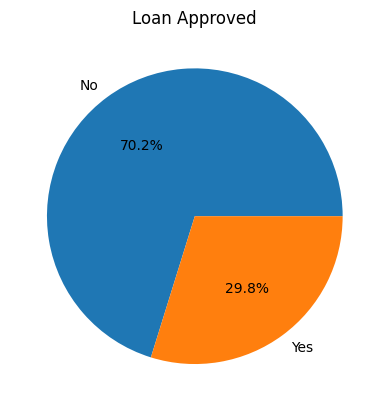

In [54]:
plt.pie(class_count,labels=['No','Yes'],autopct='%1.1f%%')
plt.title('Loan Approved')

<Axes: xlabel='Gender', ylabel='count'>

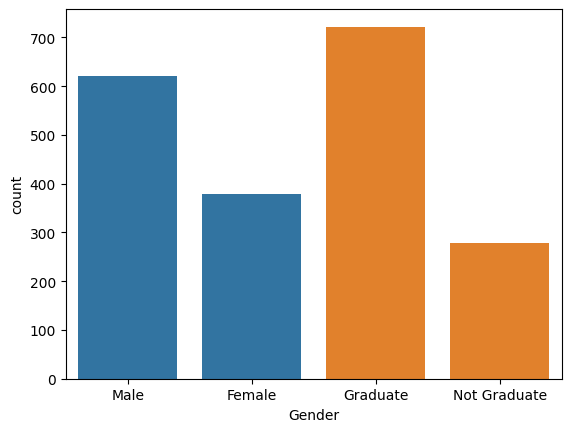

In [55]:
#Analyze Category
gender_count=df['Gender'].value_counts()
education_count=df['Education_Level'].value_counts()
sns.barplot(gender_count)
sns.barplot(education_count)

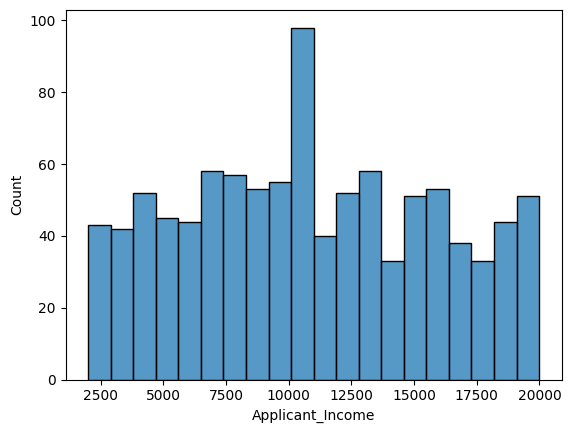

In [56]:
sns.histplot(df['Applicant_Income'], bins=20)
plt.show()


<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

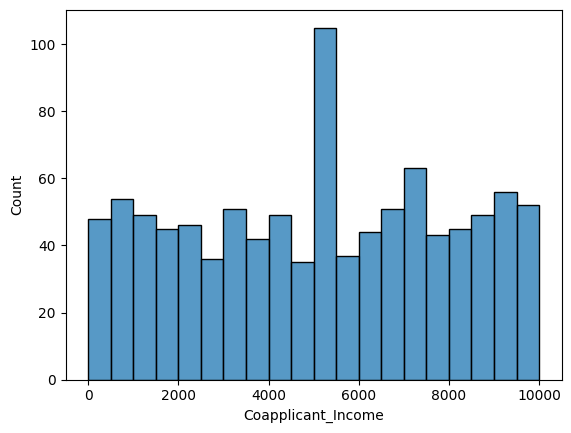

In [57]:
sns.histplot(df['Coapplicant_Income'],bins=20)

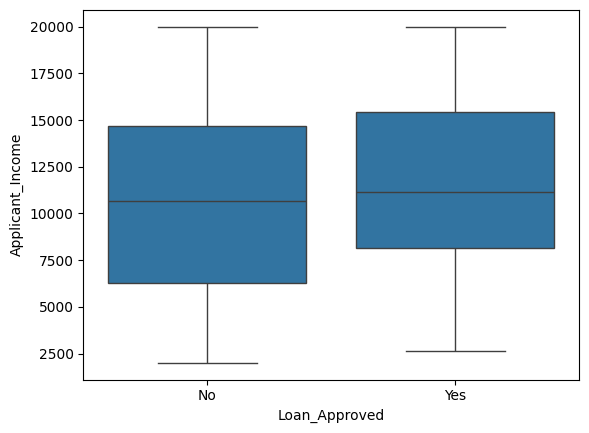

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Loan_Approved', y='Applicant_Income', data=df)
plt.show()

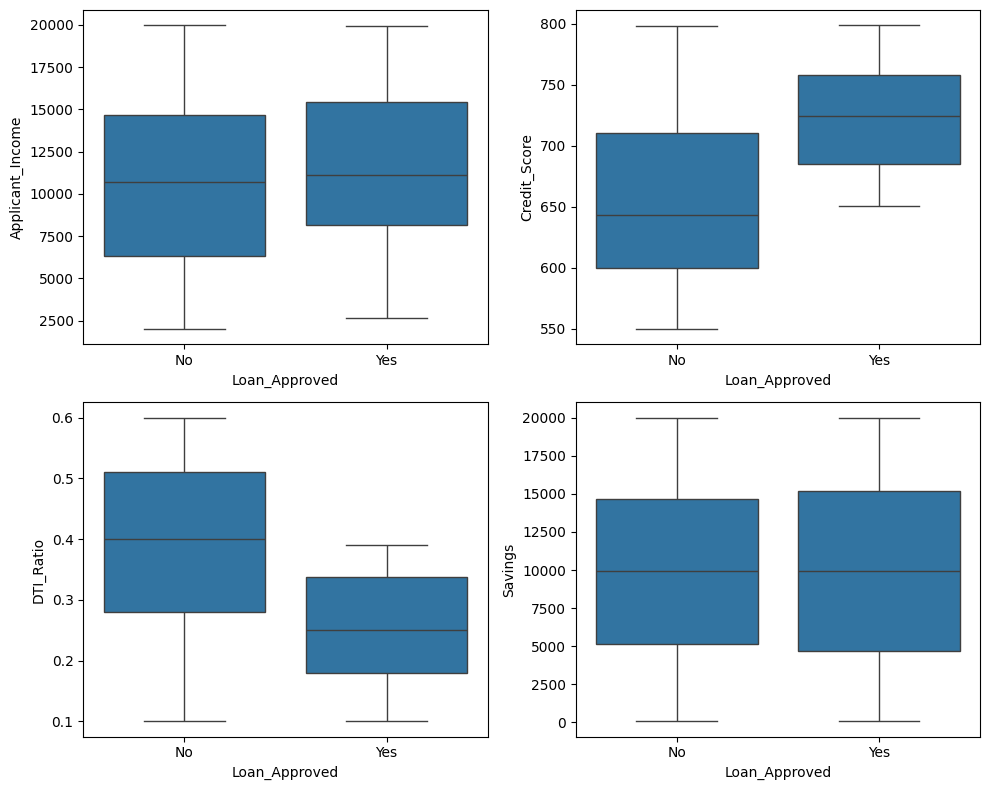

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.boxplot(ax=axes[0,0], data=df, x='Loan_Approved', y='Applicant_Income')
sns.boxplot(ax=axes[0,1], data=df, x='Loan_Approved', y='Credit_Score')
sns.boxplot(ax=axes[1,0], data=df, x='Loan_Approved', y='DTI_Ratio')
sns.boxplot(ax=axes[1,1], data=df, x='Loan_Approved', y='Savings')

plt.tight_layout()
plt.show()

In [60]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
model=LabelEncoder()
df['Education_Level']=model.fit_transform(df['Education_Level'])
df['Loan_Approved']=model.fit_transform(df['Loan_Approved'])

In [61]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

cols = ['Employment_Status','Marital_Status','Loan_Purpose',
        'Property_Area','Gender','Employer_Category']

ohe = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cols),
    index=df.index
)

In [62]:
df = pd.concat(
    [
        df.drop(columns=[
            'Employment_Status','Marital_Status','Loan_Purpose',
            'Property_Area','Gender','Employer_Category'
        ]),
        encoded_df
    ],
    axis=1
)

In [63]:
num_cols=df.select_dtypes(include="number")

In [64]:
corr_matrix=num_cols.corr()

In [66]:
X = df.drop(columns=["Loan_Approved", "Applicant_ID"])  # drop ID here
y = df["Loan_Approved"]

In [67]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [68]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_Scaler=scaler.fit_transform(X_train)
X_test_Scaler=scaler.transform(X_test)

In [69]:
X_train_Scaler

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
         2.41611400e+00, -8.59726954e-01, -3.07231582e-01]],
      shape=(800, 27))

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

In [71]:
log_model= LogisticRegression()

In [72]:
log_model.fit(X_train_Scaler,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [73]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [74]:
y_pred=log_model.predict(X_test_Scaler)

In [76]:
print("Precision Matrix : ",precision_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("F1 Score : ",f1_score(y_test,y_pred))
print("Accuracy : ",accuracy_score(y_test,y_pred))
print("F1 Score : ",f1_score(y_test,y_pred))
print("CM : ",confusion_matrix(y_test,y_pred))


Precision Matrix :  0.7833333333333333
Recall :  0.7704918032786885
F1 Score :  0.7768595041322314
Accuracy :  0.865
F1 Score :  0.7768595041322314
CM :  [[126  13]
 [ 14  47]]


In [77]:
from sklearn.neighbors import KNeighborsClassifier

In [78]:
knn_model= KNeighborsClassifier(n_neighbors=5)

In [79]:
knn_model.fit(X_train_Scaler,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [80]:
knn_pred=knn_model.predict(X_test_Scaler)

In [81]:
print("Precision Matrix : ",precision_score(y_test,knn_pred))
print("Recall : ",recall_score(y_test,knn_pred))
print("F1 Score : ",f1_score(y_test,knn_pred))
print("Accuracy : ",accuracy_score(y_test,knn_pred))
print("F1 Score : ",f1_score(y_test,knn_pred))
print("CM : ",confusion_matrix(y_test,knn_pred))


Precision Matrix :  0.6274509803921569
Recall :  0.5245901639344263
F1 Score :  0.5714285714285714
Accuracy :  0.76
F1 Score :  0.5714285714285714
CM :  [[120  19]
 [ 29  32]]


In [82]:
from sklearn.naive_bayes import GaussianNB

In [83]:
nb=GaussianNB()

In [84]:
nb.fit(X_train_Scaler,y_train)

,priors,None
,var_smoothing,1e-09


In [86]:
NB_perdict=nb.predict(X_test_Scaler)

In [87]:
print("Precision Matrix : ",precision_score(y_test,NB_perdict))
print("Recall : ",recall_score(y_test,NB_perdict))
print("F1 Score : ",f1_score(y_test,NB_perdict))
print("Accuracy : ",accuracy_score(y_test,NB_perdict))
print("F1 Score : ",f1_score(y_test,NB_perdict))
print("CM : ",confusion_matrix(y_test,NB_perdict))


Precision Matrix :  0.8035714285714286
Recall :  0.7377049180327869
F1 Score :  0.7692307692307693
Accuracy :  0.865
F1 Score :  0.7692307692307693
CM :  [[128  11]
 [ 16  45]]


In [88]:
def sales_Predict(
    Applicant_Income,
    Coapplicant_Income,
    Age,
    Dependents,
    Credit_Score,
    Existing_Loans,
    DTI_Ratio,
    Savings,
    Collateral_Value,
    Loan_Amount,
    Loan_Term,
    Education_Level,
    Employment_Status,
    Marital_Status,
    Loan_Purpose,
    Property_Area,
    Gender,
    Employer_Category
):

    data = {
        "Applicant_Income": Applicant_Income,
        "Coapplicant_Income": Coapplicant_Income,
        "Age": Age,
        "Dependents": Dependents,
        "Credit_Score": Credit_Score,
        "Existing_Loans": Existing_Loans,
        "DTI_Ratio": DTI_Ratio,
        "Savings": Savings,
        "Collateral_Value": Collateral_Value,
        "Loan_Amount": Loan_Amount,
        "Loan_Term": Loan_Term,
        "Education_Level": Education_Level,

        "Employment_Status_Salaried": 1 if Employment_Status == "Salaried" else 0,
        "Employment_Status_Self-employed": 1 if Employment_Status == "Self Employed" else 0,
        "Employment_Status_Unemployed": 1 if Employment_Status == "Unemployed" else 0,

        "Marital_Status_Single": 1 if Marital_Status == "Single" else 0,

        "Loan_Purpose_Car": 1 if Loan_Purpose == "Car" else 0,
        "Loan_Purpose_Education": 1 if Loan_Purpose == "Education" else 0,
        "Loan_Purpose_Home": 1 if Loan_Purpose == "Home" else 0,
        "Loan_Purpose_Personal": 1 if Loan_Purpose == "Personal" else 0,

        "Property_Area_Semiurban": 1 if Property_Area == "Semiurban" else 0,
        "Property_Area_Urban": 1 if Property_Area == "Urban" else 0,

        "Gender_Male": 1 if Gender == "Male" else 0,

        "Employer_Category_Government": 1 if Employer_Category == "Government" else 0,
        "Employer_Category_MNC": 1 if Employer_Category == "MNC" else 0,
        "Employer_Category_Private": 1 if Employer_Category == "Private" else 0,
        "Employer_Category_Unemployed": 1 if Employer_Category == "Unemployed" else 0,
    }

    input_df = pd.DataFrame([data])

    # ✅ Match training column order
    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    features_scaled = scaler.transform(input_df)

    prediction = nb.predict(features_scaled)

    return float(prediction[0])  

In [93]:
%%capture
pip install gradio


In [94]:
import gradio as gr

In [95]:
gr.Interface(
    fn=sales_Predict,
    inputs=[
        gr.Number(label="Applicant Income"),
        gr.Number(label="Coapplicant Income"),
        gr.Number(label="Age"),
        gr.Number(label="Dependents"),
        gr.Number(label="Credit Score"),
        gr.Number(label="Existing Loans"),
        gr.Number(label="DTI Ratio"),
        gr.Number(label="Savings"),
        gr.Number(label="Collateral Value"),
        gr.Number(label="Loan Amount"),
        gr.Number(label="Loan Term"),

        gr.Dropdown([0, 1], label="Education Level"),

        gr.Dropdown(["Salaried", "Self Employed", "Unemployed"], label="Employment Status"),
        gr.Dropdown(["Single", "Married"], label="Marital Status"),
        gr.Dropdown(["Car", "Education", "Home", "Personal"], label="Loan Purpose"),
        gr.Dropdown(["Rural", "Semiurban", "Urban"], label="Property Area"),
        gr.Dropdown(["Male", "Female"], label="Gender"),
        gr.Dropdown(["Government", "MNC", "Private", "Unemployed"], label="Employer Category"),
    ],
    outputs=gr.Number(label="Prediction (0 = Reject, 1 = Approve)"),
    title="Loan Approval Prediction",
    description="Enter applicant details"
).launch(share=True)

* Running on local URL:  http://127.0.0.1:7863
* Running on public URL: https://60ad035aaffb7bf71e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
